In [1]:
!pip install -q -U scikit-learn pandas ipywidgets

In [2]:
import torch
import torch.optim as optim

import numpy as np
import random

import matplotlib.pyplot as plt
from tqdm import tqdm


# ANSI codes
BOLD     = "\033[1m"
RED      = "\033[31m"
GREEN    = "\033[32m"
RESET    = "\033[0m"


In [3]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X.reshape(-1, 28, 28)  # optional: reshape from (70000, 784) to (70000, 28, 28)

# Split if needed
X_train, y_train = X[:60000], y[:60000]
X_test, y_test = X[60000:], y[60000:]

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)


X_train = (X_train - 128)/128

X_test = (X_test - 128)/128

X_train.min(),X_train.max()

(np.float64(-1.0), np.float64(0.9921875))

In [24]:
model = torch.nn.Sequential(
    # encoder
    torch.nn.Linear(X_train.shape[1],500), torch.nn.ReLU(),
    torch.nn.Linear(500,100), torch.nn.ReLU(),

    # decoder
    torch.nn.Linear(100,500), torch.nn.ReLU(),
    torch.nn.Linear(500,X_train.shape[1])
)
model = torch.compile(model)

In [25]:
optimizer = optim.Adam(model.parameters(), lr=5e-4, amsgrad=True)
lossfn = torch.nn.MSELoss()

In [26]:
EPOCHS = 50
pbar = tqdm(range(EPOCHS), colour='blue', ncols=70, position=0)
X = torch.Tensor(X_train)

BSIZE = 1000
batches = range(0,X.shape[0],BSIZE)
for _ in pbar:
    for b in batches:
        x = X[b:b+BSIZE]
        loss = lossfn(model(x),x)
        
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    pbar.set_postfix_str(f"loss:{float(loss*100):.3f}%")

100%|████████████████████| 50/50 [00:16<00:00,  2.97it/s, loss:4.029%]


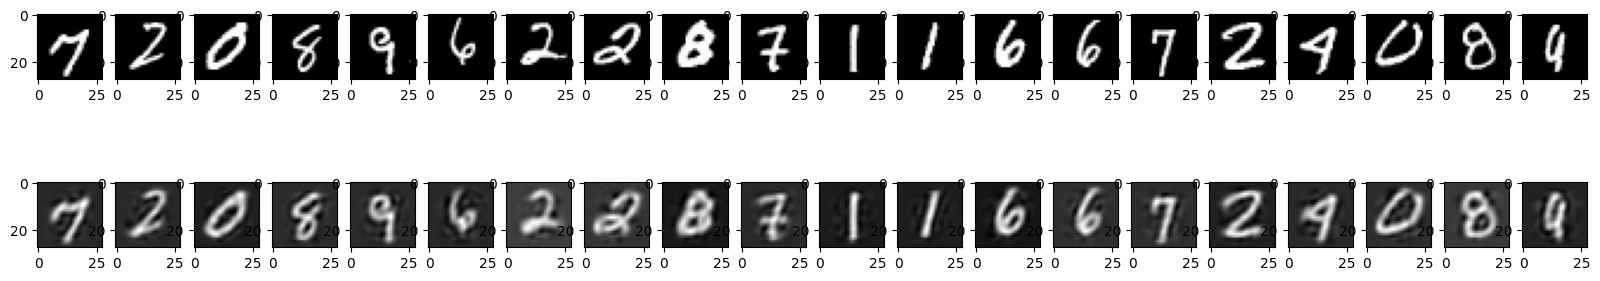

In [27]:
random20 = list(map(lambda _:random.randint(0,X_test.shape[0]), range(20)))
xtest = X_test[random20]
xtest_hat = model(torch.Tensor(xtest)).detach().numpy()


plt.figure(figsize=(20,4))
for i in range(20):
    plt.subplot(2,20,1+i)
    plt.imshow(xtest[i].reshape(28,28), cmap='gray')
    
    plt.subplot(2,20,21+i)
    plt.imshow(xtest_hat[i].reshape(28,28), cmap='gray')

Reconstruction Error: 4.23%


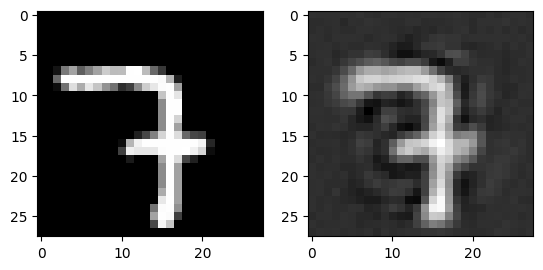

In [32]:
random_id = random.randint(0,X_test.shape[0])
x = X_test[random_id:random_id+1]
x_hat = model(torch.Tensor(x)).detach().numpy()

plt.subplot(1,2,1)
plt.imshow(x.reshape(28,28), cmap='gray')

plt.subplot(1,2,2)
plt.imshow(x_hat.reshape(28,28), cmap='gray')

print(f"Reconstruction Error: {BOLD}{GREEN}{100*lossfn(torch.Tensor(x), torch.Tensor(x_hat)):.2f}%")

Reconstruction Error: 7.67%


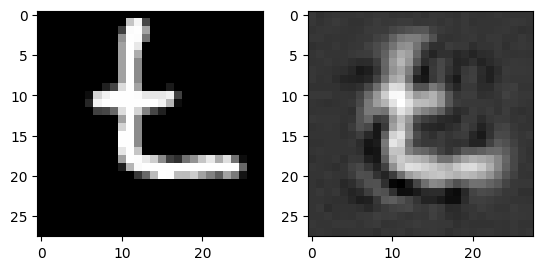

In [33]:
x_flipped = x[:,::-1].copy()
x_flipped_hat = model(torch.Tensor(x_flipped)).detach().numpy()

plt.subplot(1,2,1)
plt.imshow(x_flipped.reshape(28,28), cmap='gray')

plt.subplot(1,2,2)
plt.imshow(x_flipped_hat.reshape(28,28), cmap='gray')

print(f"Reconstruction Error: {BOLD}{RED}{100*lossfn(torch.Tensor(x_flipped), torch.Tensor(x_flipped_hat)):.2f}%")

In [22]:
# COMMENTS

# 1. Reconstruction Error is higher when Flipped/Rotated

# We can detect anomaly by looking at the how many standard deviations away is the reconstruction error of an input and then use a suitable threshold to mark as anomalous if beyond that threshold